# Work02：解析本地 PDF 首页并总结内容

In [8]:
import base64
import io
import os
from pathlib import Path

import fitz
from IPython.display import display
from openai import OpenAI
from PIL import Image

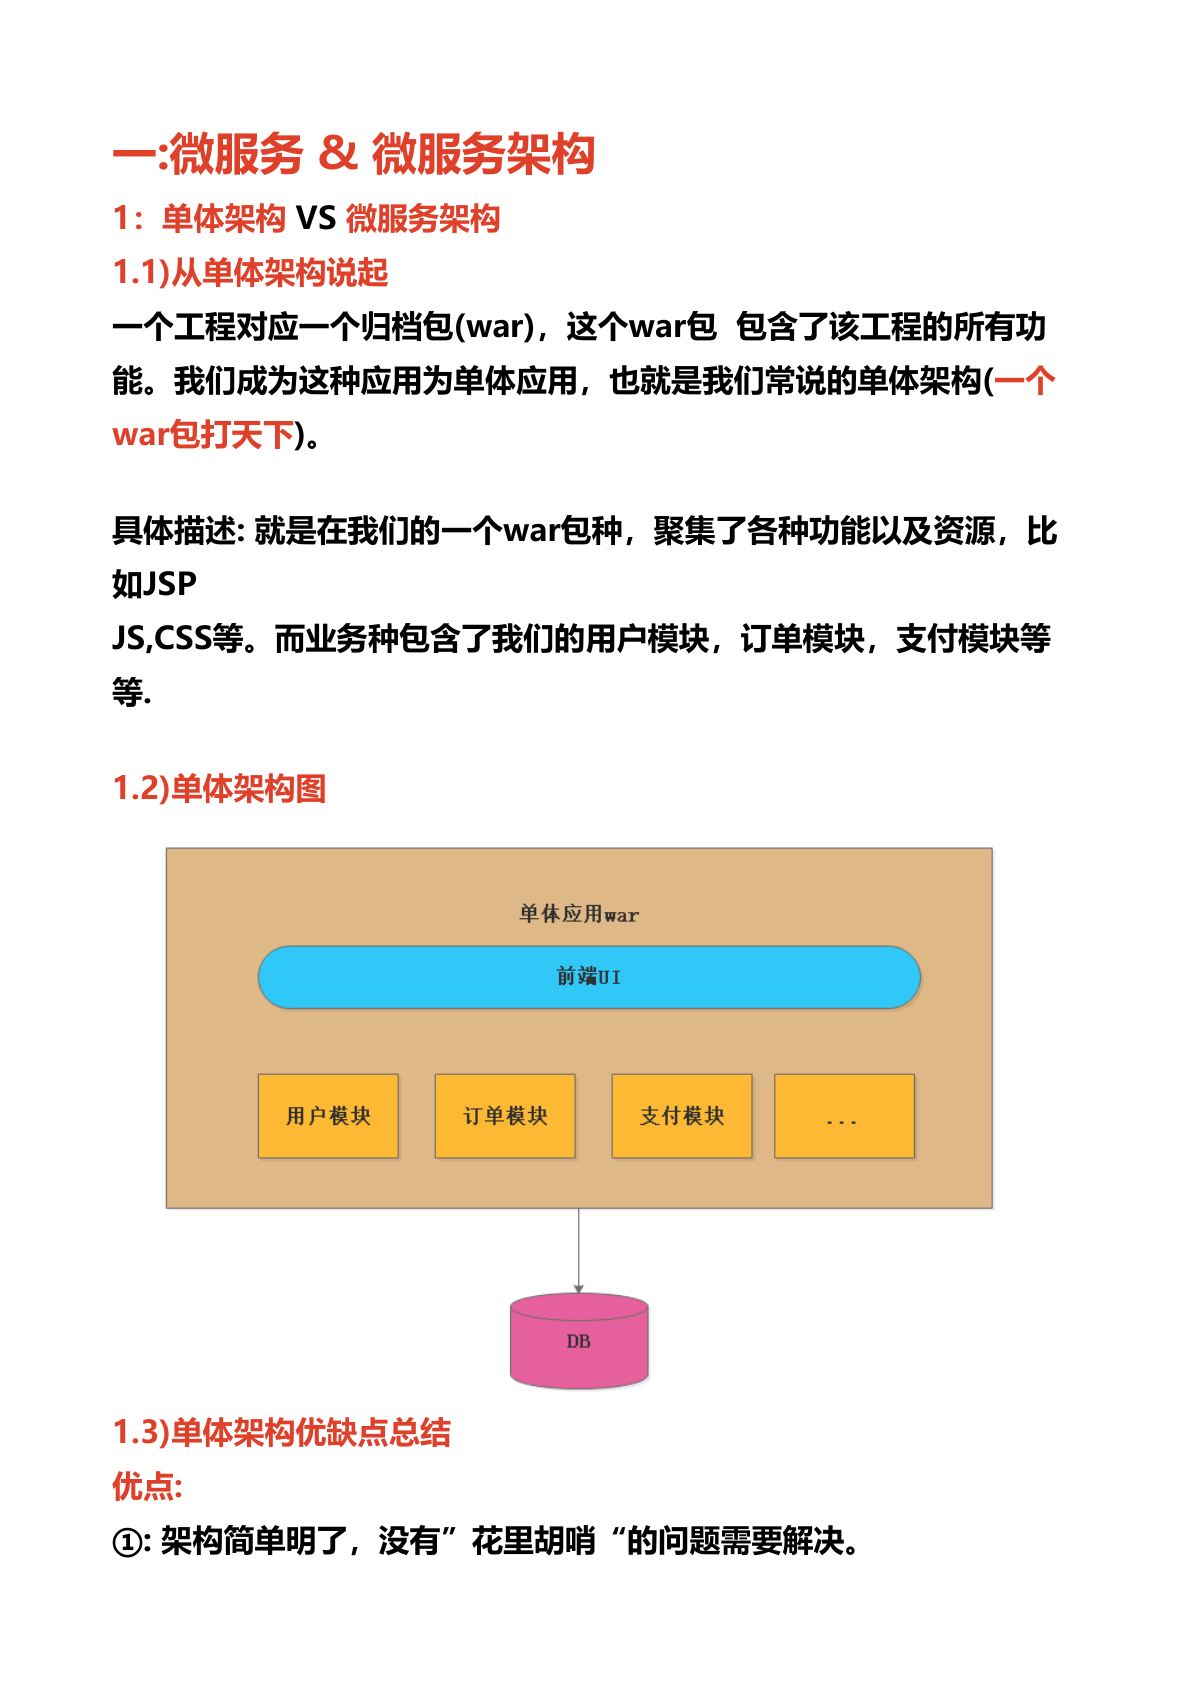

pdf: 微服务入门&Nocas实操.pdf
page: 1


In [9]:
base_dir = Path.cwd()
pdf_path = base_dir / "微服务入门&Nocas实操.pdf"
page_number = 0

doc = fitz.open(pdf_path)
page = doc.load_page(page_number)
pix = page.get_pixmap(matrix=fitz.Matrix(2, 2), alpha=False)
page_image = Image.open(io.BytesIO(pix.tobytes("png"))).convert("RGB")
display(page_image)
print(f"pdf: {pdf_path.name}")
print(f"page: {page_number + 1}")

In [12]:
buffer = io.BytesIO()
page_image.save(buffer, format="PNG")
image_base64 = base64.b64encode(buffer.getvalue()).decode("utf-8")
image_url = f"data:image/png;base64,{image_base64}"

base_url = os.getenv("OPENAI_BASE_URL", "https://dashscope.aliyuncs.com/compatible-mode/v1")
api_key = os.getenv("OPENAI_API_KEY", "sk-89beb5cc538544fc9ab0ad56bcf6f044")
model_name = os.getenv("OPENAI_MODEL", "qwen3-vl-plus")

client = OpenAI(api_key=api_key, base_url=base_url)
print(base_url)
print(model_name)

https://dashscope.aliyuncs.com/compatible-mode/v1
qwen3-vl-plus


In [13]:
response = client.chat.completions.create(
    model=model_name,
    messages=[
        {
            "role": "user",
            "content": [
                {
                    "type": "text",
                    "text": "请阅读这份《微服务入门&Nocas实操》PDF 的第一页，先判断这页主要属于目录、封面、正文还是流程图页，再用 3 到 5 条中文要点总结这页主要讲了什么。"
                },
                {
                    "type": "image_url",
                    "image_url": {"url": image_url}
                }
            ]
        }
    ]
)

answer = response.choices[0].message.content
print(answer)

这页属于**正文页**（具体为章节起始的讲解与图示页，非封面、目录或纯流程图）。

主要要点如下：

1. **引入单体架构概念**：以一个 war 包为例，说明单体应用将所有功能（如 JSP、JS、CSS）和业务模块（用户、订单、支付等）集中在一个部署单元中，即“一个 war 包打天下”。

2. **展示单体架构图**：图中呈现“单体应用 war”包含前端 UI 与多个业务模块（用户、订单、支付等），统一连接至单一数据库（DB），体现其紧耦合特征。

3. **总结单体架构优点**：首条优点为架构简单明了，避免“花里胡哨”的设计问题，强调其开发与部署的简易性（后续可能对比微服务缺点）。
